# Visual-language assistant with Qwen3-VL and OpenVINO

Qwen3-VL is the latest addition to the QwenVL series of multimodal large language models.

This generation delivers comprehensive upgrades across the board: superior text understanding & generation, deeper visual perception & reasoning, extended context length, enhanced spatial and video dynamics comprehension, and stronger agent interaction capabilities.

Available in Dense and MoE architectures that scale from edge to cloud, with Instruct and reasoning‑enhanced Thinking editions for flexible, on‑demand deployment.


#### Key Enhancements:

* **Visual Agent**: Operates PC/mobile GUIs—recognizes elements, understands functions, invokes tools, completes tasks.

* **Visual Coding Boost**: Generates Draw.io/HTML/CSS/JS from images/videos.

* **Advanced Spatial Perception**: Judges object positions, viewpoints, and occlusions; provides stronger 2D grounding and enables 3D grounding for spatial reasoning and embodied AI.

* **Long Context & Video Understanding**: Native 256K context, expandable to 1M; handles books and hours-long video with full recall and second-level indexing.

* **Enhanced Multimodal Reasoning**: Excels in STEM/Math—causal analysis and logical, evidence-based answers.

* **Upgraded Visual Recognition**: Broader, higher-quality pretraining is able to “recognize everything”—celebrities, anime, products, landmarks, flora/fauna, etc.

* **Expanded OCR**: Supports 32 languages (up from 19); robust in low light, blur, and tilt; better with rare/ancient characters and jargon; improved long-document structure parsing.

* **Text Understanding on par with pure LLMs**: Seamless text–vision fusion for lossless, unified comprehension.


#### Model Architecture Updates:

<p align="center">
    <img src="https://qianwen-res.oss-accelerate.aliyuncs.com/Qwen3-VL/qwen3vl_arc.jpg" width="80%"/>
<p>


1. **Interleaved-MRoPE**: Full‑frequency allocation over time, width, and height via robust positional embeddings, enhancing long‑horizon video reasoning.

2. **DeepStack**: Fuses multi‑level ViT features to capture fine‑grained details and sharpen image–text alignment.

3. **Text–Timestamp Alignment:** Moves beyond T‑RoPE to precise, timestamp‑grounded event localization for stronger video temporal modeling.


More details about model can be found in [model card](https://huggingface.co/Qwen/Qwen3-VL-4B-Instruct), [blog](https://qwen.ai/blog?id=99f0335c4ad9ff6153e517418d48535ab6d8afef&from=research.latest-advancements-list) and original [repo](https://github.com/QwenLM/Qwen3-VL).

In this tutorial we consider how to convert and optimize Qwen3VL model for creating multimodal chatbot using [Optimum Intel](https://github.com/huggingface/optimum-intel). Additionally, we demonstrate how to apply model optimization techniques like weights compression using [NNCF](https://github.com/openvinotoolkit/nncf).

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Select model](#Select-model)
- [Convert and Optimize model](#Convert-and-Optimize-model)
    - [Compress model weights to 4-bit](#Compress-model-weights-to-4-bit)
- [Prepare model inference pipeline](#Prepare-model-inference-pipeline)
    - [Select inference device](#Select-inference-device)
- [Run model inference](#Run-model-inference)
- [Interactive Demo](#Interactive-Demo)


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/qwen2.5-vl/qwen2.5-vl.ipynb" />


<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks\qwen3-vl\qwen3-vl.ipynb" />


<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/qwen3-vl/qwen3-vl.ipynb" />


## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [1]:
import platform

%pip install -q "torch>=2.1,<2.9" "torchvision" "qwen-vl-utils" "Pillow" "gradio>=4.36" --extra-index-url https://download.pytorch.org/whl/cpu
%pip uninstall -q -y "optimum" "transformers" "optimum-intel"
%pip install -q git+https://github.com/openvino-dev-samples/optimum.git@qwen3vl
%pip install -q git+https://github.com/openvino-dev-samples/transformers.git@qwen3vl
%pip install -q git+https://github.com/openvino-dev-samples/optimum-intel.git@qwen3vl
%pip install -q nncf
%pip install -q -U openvino==2025.3

if platform.system() == "Darwin":
    %pip install -q "numpy<2.0"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import requests

if not Path("cmd_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py")
    open("cmd_helper.py", "w").write(r.text)

if not Path("notebook_utils.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    open("notebook_utils.py", "w").write(r.text)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("qwen3-vl.ipynb")

## Select model
[back to top ⬆️](#Table-of-contents:)

There are multiple Qwen3VL models available in [models collection](https://huggingface.co/collections/Qwen/qwen3-vl-68d2a7c1b8a8afce4ebd2dbe). You can select one of them for conversion and optimization in notebook using widget bellow:

In [ ]:
import ipywidgets as widgets

model_ids = ["Qwen/Qwen3-VL-2B-Instruct", "Qwen/Qwen3-VL-4B-Instruct", "Qwen/Qwen3-VL-8B-Instruct"]

model_id = widgets.Dropdown(
    options=model_ids,
    default=model_ids[0],
    description="Model:",
)

model_id

Dropdown(description='Model:', options=('Qwen/Qwen3-VL-4B-Instruct', 'Qwen/Qwen3-VL-8B-Instruct'), value='Qwen…

In [4]:
print(f"Selected {model_id.value}")
pt_model_id = model_id.value
model_dir = Path(pt_model_id.split("/")[-1])

Selected Qwen/Qwen3-VL-4B-Instruct


## Convert and Optimize model
[back to top ⬆️](#Table-of-contents:)

Qwen3VL is PyTorch model. OpenVINO supports PyTorch models via conversion to OpenVINO Intermediate Representation (IR). [OpenVINO model conversion API](https://docs.openvino.ai/2024/openvino-workflow/model-preparation.html#convert-a-model-with-python-convert-model) should be used for these purposes. `ov.convert_model` function accepts original PyTorch model instance and example input for tracing and returns `ov.Model` representing this model in OpenVINO framework. Converted model can be used for saving on disk using `ov.save_model` function or directly loading on device using `core.compile_model`. 

For convenience, we will use OpenVINO integration with HuggingFace Optimum. 🤗 [Optimum Intel](https://huggingface.co/docs/optimum/intel/index) is the interface between the 🤗 Transformers and Diffusers libraries and the different tools and libraries provided by Intel to accelerate end-to-end pipelines on Intel architectures.

Among other use cases, Optimum Intel provides a simple interface to optimize your Transformers and Diffusers models, convert them to the OpenVINO Intermediate Representation (IR) format and run inference using OpenVINO Runtime. `optimum-cli` provides command line interface for model conversion and optimization. 

General command format:

```bash
optimum-cli export openvino --model <model_id_or_path> --task <task> <output_dir>
```

where task is task to export the model for, if not specified, the task will be auto-inferred based on the model. You can find a mapping between tasks and model classes in Optimum TaskManager [documentation](https://huggingface.co/docs/optimum/exporters/task_manager). Additionally, you can specify weights compression using `--weight-format` argument with one of following options: `fp32`, `fp16`, `int8` and `int4`. Fro int8 and int4 [nncf](https://github.com/openvinotoolkit/nncf) will be used for  weight compression. More details about model export provided in [Optimum Intel documentation](https://huggingface.co/docs/optimum/intel/openvino/export#export-your-model).


### Compress model weights to 4-bit
[back to top ⬆️](#Table-of-contents:)
For reducing memory consumption, weights compression optimization can be applied using [NNCF](https://github.com/openvinotoolkit/nncf). 

<details>
    <summary><b>Click here for more details about weight compression</b></summary>
Weight compression aims to reduce the memory footprint of a model. It can also lead to significant performance improvement for large memory-bound models, such as Large Language Models (LLMs). LLMs and other models, which require extensive memory to store the weights during inference, can benefit from weight compression in the following ways:

* enabling the inference of exceptionally large models that cannot be accommodated in the memory of the device;

* improving the inference performance of the models by reducing the latency of the memory access when computing the operations with weights, for example, Linear layers.

[Neural Network Compression Framework (NNCF)](https://github.com/openvinotoolkit/nncf) provides 4-bit / 8-bit mixed weight quantization as a compression method primarily designed to optimize LLMs. The main difference between weights compression and full model quantization (post-training quantization) is that activations remain floating-point in the case of weights compression which leads to a better accuracy. Weight compression for LLMs provides a solid inference performance improvement which is on par with the performance of the full model quantization. In addition, weight compression is data-free and does not require a calibration dataset, making it easy to use.

`nncf.compress_weights` function can be used for performing weights compression. The function accepts an OpenVINO model and other compression parameters. Compared to INT8 compression, INT4 compression improves performance even more, but introduces a minor drop in prediction quality.

More details about weights compression, can be found in [OpenVINO documentation](https://docs.openvino.ai/2024/openvino-workflow/model-optimization-guide/weight-compression.html).
</details>

In [5]:
from cmd_helper import optimum_cli

if not (model_dir / "INT4").exists():
    optimum_cli(pt_model_id, model_dir / "INT4", additional_args={"weight-format": "int4"})

## Prepare model inference pipeline
[back to top ⬆️](#Table-of-contents:)

OpenVINO integration with Optimum Intel provides ready-to-use API for model inference that can be used for smooth integration with transformers-based solutions. For loading model, we will use `OVModelForVisualCausalLM` class that have compatible interface with Transformers Qwen3VL implementation. For loading a model, `from_pretrained` method should be used. It accepts path to the model directory or model_id from HuggingFace hub (if model is not converted to OpenVINO format, conversion will be triggered automatically). Additionally, we can provide an inference device, quantization config (if model has not been quantized yet) and device-specific OpenVINO Runtime configuration. More details about model inference with Optimum Intel can be found in [documentation](https://huggingface.co/docs/optimum/intel/openvino/inference).

In [6]:
from optimum.intel.openvino import OVModelForVisualCausalLM

D:\openvino_notebooks\py_env\Lib\site-packages\torch\onnx\_internal\registration.py:162: OnnxExporterWarning: Symbolic function 'aten::scaled_dot_product_attention' already registered for opset 14. Replacing the existing function with new function. This is unexpected. Please report it on https://github.com/pytorch/pytorch/issues.
  warnings.warn(


### Select inference device
[back to top ⬆️](#Table-of-contents:)

In [7]:
from notebook_utils import device_widget

device = device_widget(default="AUTO", exclude=["NPU"])

device

Dropdown(description='Device:', index=2, options=('CPU', 'GPU', 'AUTO'), value='AUTO')

In [8]:
model = OVModelForVisualCausalLM.from_pretrained(model_dir / "INT4", device=device.value)

## Run model inference
[back to top ⬆️](#Table-of-contents:)

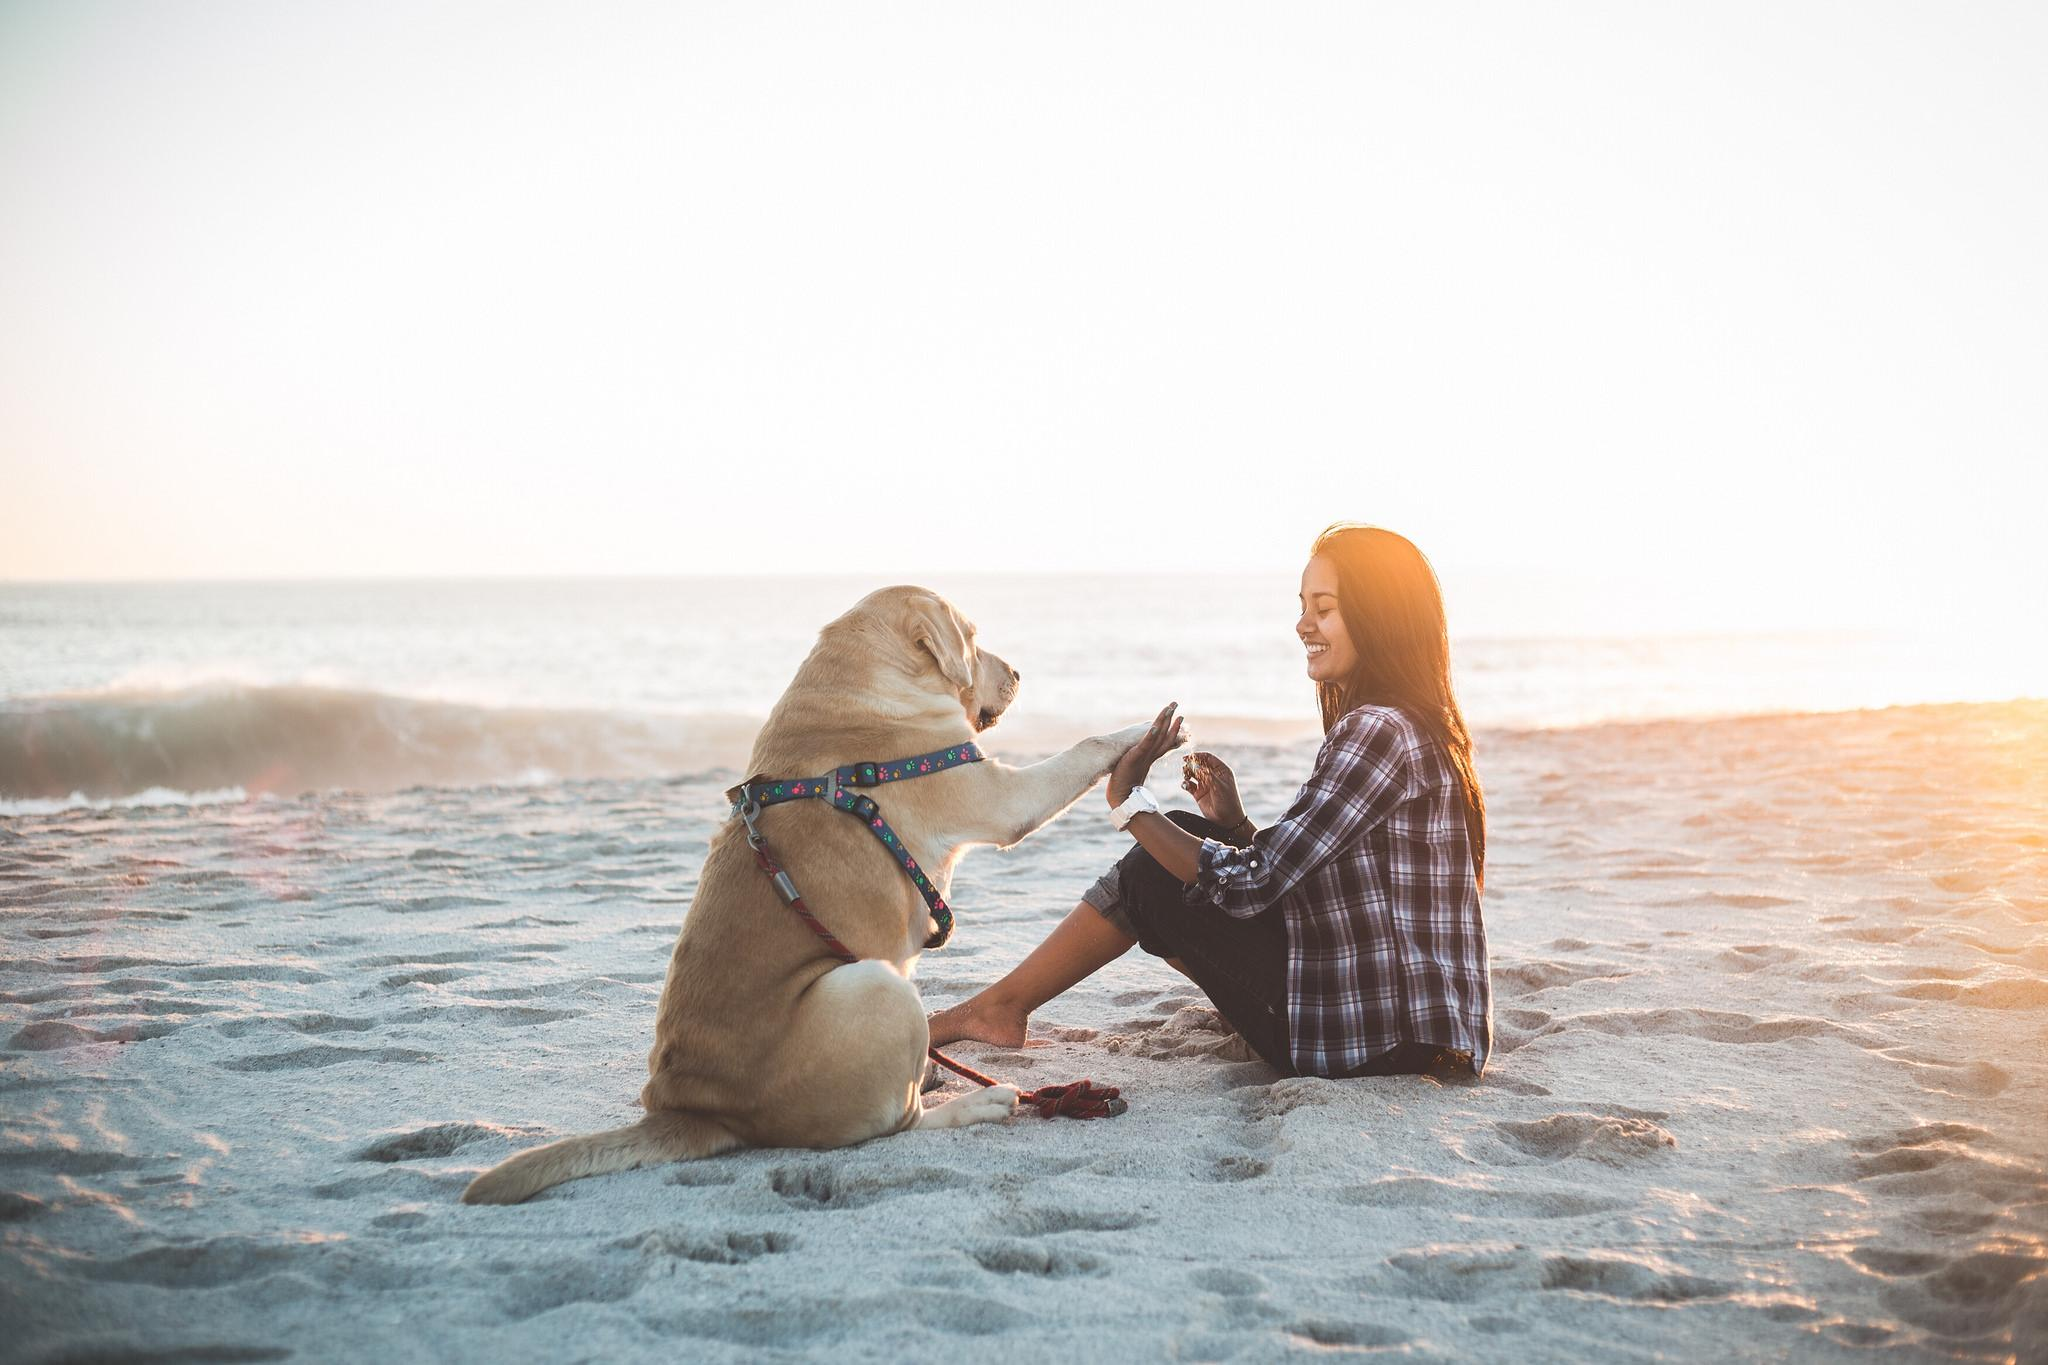

Question:
Describe this image.
Answer:
This is a warm, heartwarming photograph capturing a tender moment between a woman and her dog on a beach at sunset.

**Key Details:**

*   **Subjects:** A woman with long dark hair, wearing a plaid shirt, is sitting cross-legged in the sand. She is smiling gently, looking at her dog. The dog, a large, light-colored Labrador Retriever, is sitting on its haunches, wearing a colorful harness, and has its front paw extended toward her


In [ ]:
from PIL import Image
from transformers import AutoProcessor
from transformers import TextStreamer


min_pixels = 256 * 28 * 28
max_pixels = 1280 * 28 * 28
processor = AutoProcessor.from_pretrained(model_dir / "INT4", min_pixels=min_pixels, max_pixels=max_pixels)

# if processor.chat_template is None:
#     tok = AutoTokenizer.from_pretrained(model_dir)
#     processor.chat_template = tok.chat_template

example_image_url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg"
example_image_path = Path("demo.jpeg")

if not example_image_path.exists():
    Image.open(requests.get(example_image_url, stream=True).raw).save(example_image_path)

image = Image.open(example_image_path)
question = "Describe this image."

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "url": f"{example_image_url}",
            },
            {"type": "text", "text": question},
        ],
    }
]

# Preparation for inference
inputs = processor.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_dict=True, return_tensors="pt")

display(image)
print("Question:")
print(question)
print("Answer:")

generated_ids = model.generate(**inputs, max_new_tokens=100, streamer=TextStreamer(processor.tokenizer, skip_prompt=True, skip_special_tokens=True))

In [10]:
if not Path("gradio_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/qwen2-vl/gradio_helper.py")
    open("gradio_helper.py", "w").write(r.text)

## Interactive Demo
[back to top ⬆️](#Table-of-contents:)

Now, you can try to chat with model. Upload image or video using `Upload` button, provide your text message into `Input` field and click `Submit` to start communication.

In [ ]:
from gradio_helper import make_demo


demo = make_demo(model, processor)

try:
    demo.launch(debug=True)
except Exception:
    demo.launch(debug=True, share=True)
# if you are launching remotely, specify server_name and server_port
# demo.launch(server_name='your server name', server_port='server port in int')
# Read more in the docs: https://gradio.app/docs/